# Medical Insurance Charges — Multivariate Regression Analysis

**Mission:** Identify the key factors that drive individual healthcare costs in the United States to help insurers and policymakers design more equitable and affordable medical coverage.

**Dataset:** Medical Cost Personal Dataset — Kaggle  
**Source:** https://www.kaggle.com/datasets/mirichoi0218/insurance  
**Records:** 1,338 individuals | **Features:** 6 inputs + 1 target  

**Target:** `charges` — annual medical insurance cost in USD (continuous)

## Step 1: Import All Required Libraries

This step loads all libraries needed throughout the project.
`pandas` and `numpy` handle data loading and numerical operations.
`matplotlib` and `seaborn` produce all visualisations.
From scikit-learn we import preprocessing tools (`LabelEncoder`, `StandardScaler`),
`train_test_split`, three regression models (`LinearRegression`, `SGDRegressor`,
`DecisionTreeRegressor`, `RandomForestRegressor`), and evaluation metrics
(`MSE`, `MAE`, `R2`). `joblib` saves the best model for reuse without retraining.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

We load the Medical Cost Personal Dataset. Each row represents one individual and includes demographic and health attributes alongside their annual insurance charges.

In [2]:
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print(df.info())
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

--- Descriptive Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Step 3: Feature Engineering — Checking Unique Categorical Values

Before encoding, we inspect each categorical column to understand cardinality and decide the best encoding strategy.

In [4]:
print("Columns:", df.columns.tolist())
print()
print("sex     unique:", df['sex'].unique())
print("smoker  unique:", df['smoker'].unique())
print("region  unique:", df['region'].unique())
print()
print("children range: 0 —", df['children'].max())
print("age range:     ", df['age'].min(), "—", df['age'].max())
print("bmi range:     ", df['bmi'].min(), "—", df['bmi'].max())
print("charges range: ", round(df['charges'].min(),2), "—", round(df['charges'].max(),2))

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

sex     unique: <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker  unique: <StringArray>
['yes', 'no']
Length: 2, dtype: str
region  unique: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

children range: 0 — 5
age range:      18 — 64
bmi range:      15.96 — 53.13
charges range:  1121.87 — 63770.43


## Step 4: Data Cleaning

We check for missing values and duplicate rows.
All 6 features are retained — each provides unique information:
- `age`, `bmi`, `children` are direct health/demographic predictors.
- `smoker` is expected to be the strongest predictor of high charges.
- `sex` and `region` add demographic and geographic context.
No columns are dropped; all contribute meaningful signal.

In [5]:
print("--- Null Values ---")
print(df.isnull().sum())
n_dups = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dups}")
if n_dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {n_dups} duplicate. New shape: {df.shape}")

--- Null Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1
Dropped 1 duplicate. New shape: (1337, 7)


## Step 5: Exploratory Data Analysis and Visualizations

### Visualization 1 — Correlation Heatmap

**Interpretation:** After encoding categoricals, the heatmap shows that `smoker` has the strongest correlation with `charges` — smokers pay dramatically more. `age` and `bmi` also show meaningful positive correlations, confirming their importance as predictors. `sex`, `region`, and `children` have weaker correlations.

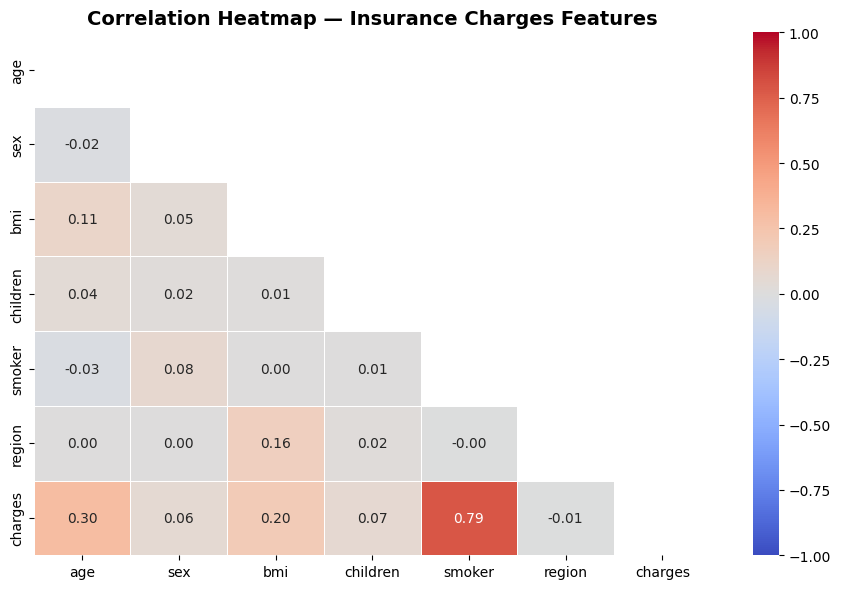


--- Correlation with Charges ---
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
region     -0.006547
Name: charges, dtype: float64


In [6]:
df_temp = df.copy()
df_temp['sex']    = df_temp['sex'].map({'female': 0, 'male': 1})
df_temp['smoker'] = df_temp['smoker'].map({'no': 0, 'yes': 1})
df_temp['region'] = LabelEncoder().fit_transform(df_temp['region'])

plt.figure(figsize=(9, 6))
corr_matrix = df_temp.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap — Insurance Charges Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Correlation with Charges ---")
print(corr_matrix['charges'].sort_values(ascending=False))

### Visualization 2 — Key Features vs Charges (coloured by Smoker Status)

**Interpretation:** Colouring by `smoker` reveals a striking pattern — smokers (red) cluster at much higher charges regardless of age or BMI. Among non-smokers (blue), charges scale gradually with age and BMI. This shows that `smoker` acts as a multiplicative cost factor and is the most critical feature in the model.

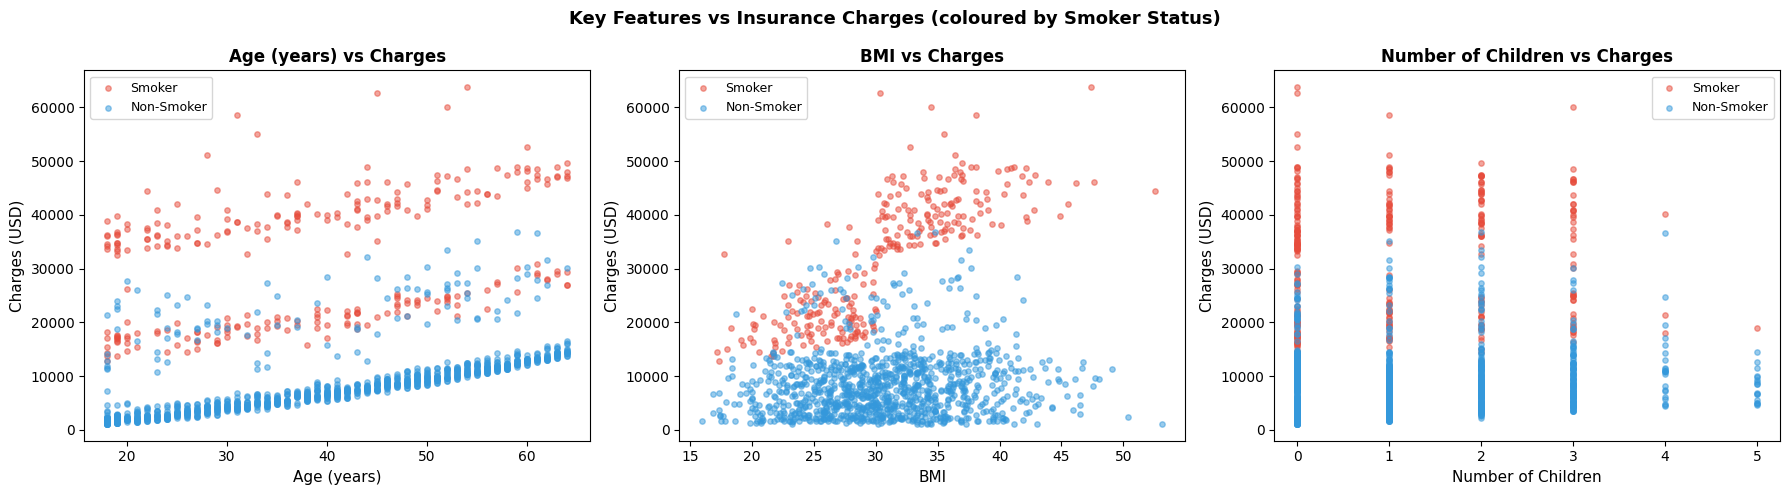

In [7]:
colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, xcol, xlabel in zip(
    axes,
    ['age', 'bmi', 'children'],
    ['Age (years)', 'BMI', 'Number of Children']
):
    for status, color, label in [('yes','#e74c3c','Smoker'), ('no','#3498db','Non-Smoker')]:
        sub = df[df['smoker'] == status]
        ax.scatter(sub[xcol], sub['charges'], color=color, alpha=0.5, s=15, label=label)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Charges (USD)', fontsize=11)
    ax.set_title(f'{xlabel} vs Charges', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Key Features vs Insurance Charges (coloured by Smoker Status)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 3 — Charges Distribution by Smoker Status and Region

**Interpretation:** Smokers consistently show higher and more variable charges across all regions. The regional effect is minor in comparison, confirming that `smoker` dominates the cost signal while `region` contributes marginal variation.

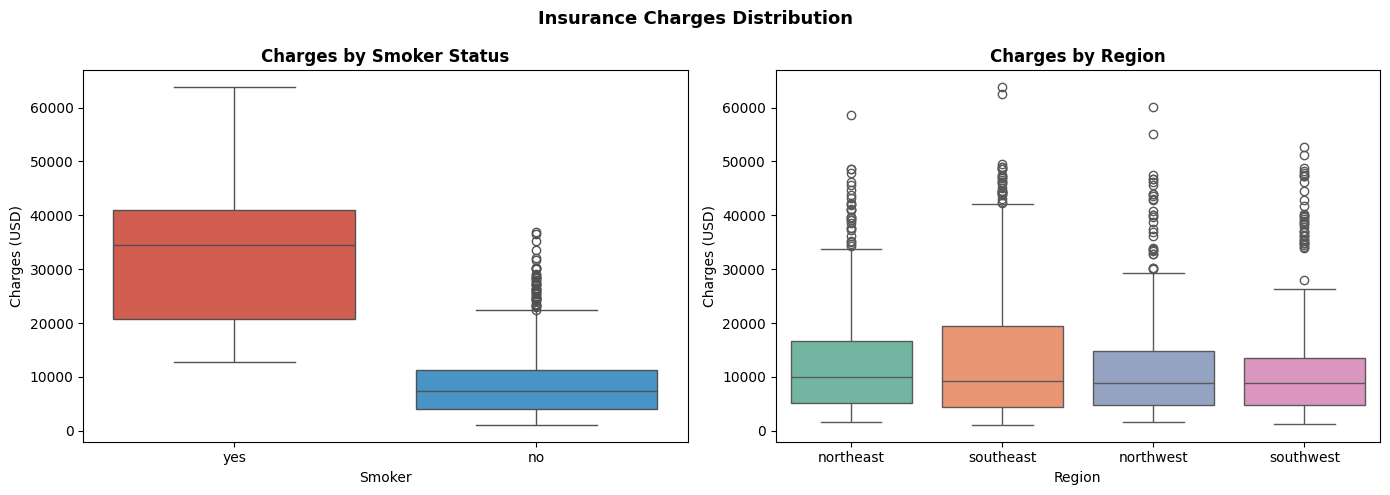

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='smoker', y='charges', palette={'yes':'#e74c3c','no':'#3498db'}, ax=axes[0])
axes[0].set_title('Charges by Smoker Status', fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges (USD)')

region_order = df.groupby('region')['charges'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='charges', order=region_order, palette='Set2', ax=axes[1])
axes[1].set_title('Charges by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Charges (USD)')

plt.suptitle('Insurance Charges Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Encoding Categorical Columns — Converting Text to Numbers

Machine learning models require numeric inputs. We apply:
- **`sex`** → Binary encoding: `female = 0`, `male = 1`
- **`smoker`** → Binary encoding: `no = 0`, `yes = 1`
- **`region`** → Label encoding across 4 categories (northeast, northwest, southeast, southwest)

In [9]:
df_encoded = df.copy()

df_encoded['sex']    = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

le_region = LabelEncoder()
df_encoded['region'] = le_region.fit_transform(df_encoded['region'])

print("Encoding complete:")
print(f"  sex     : female=0, male=1")
print(f"  smoker  : no=0, yes=1")
print(f"  region  : {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}")
print()
df_encoded.head()

Encoding complete:
  sex     : female=0, male=1
  smoker  : no=0, yes=1
  region  : {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}



,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Step 7: Defining Features, Train/Test Split and Standardization

We use all 6 features as inputs. The data is split 80/20 and `StandardScaler` is applied so all features operate on the same scale — essential for gradient descent.

In [10]:
FEATURES = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
TARGET   = 'charges'

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train size: 1069 | Test size: 268


## Step 8: Standardization Verification

Confirming that after scaling, feature means are ~0 and standard deviations are ~1.

In [11]:
print(" Standardization Verification:")
print(f"   Training set mean (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"   Training set std  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

 Standardization Verification:
   Training set mean (should be ~0): [0. 0. 0. 0. 0. 0.]
   Training set std  (should be ~1): [1. 1. 1. 1. 1. 1.]


## Step 9: Linear Regression Model with Gradient Descent and Loss Curves

### Standard Linear Regression (scikit-learn)

We first train a standard `LinearRegression` as a closed-form OLS baseline.

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr  = lr_model.predict(X_test_scaled)

lr_train_mse = mean_squared_error(y_train, y_pred_train_lr)
lr_test_mse  = mean_squared_error(y_test,  y_pred_test_lr)
lr_r2        = r2_score(y_test, y_pred_test_lr)

print("Linear Regression (OLS)")
print(f"  Train MSE : {lr_train_mse:,.2f}  |  Test MSE : {lr_test_mse:,.2f}")
print(f"  Train RMSE: {np.sqrt(lr_train_mse):,.2f}  |  Test RMSE: {np.sqrt(lr_test_mse):,.2f}")
print(f"  Test  R2  : {lr_r2:.4f}")

Linear Regression (OLS)
  Train MSE : 37,005,531.73  |  Test MSE : 35,493,102.61
  Train RMSE: 6,083.22  |  Test RMSE: 5,957.61
  Test  R2  : 0.8068


### Gradient Descent Training using NumPy

We implement **batch gradient descent** from scratch with random weight initialisation so the full convergence trajectory is visible in the loss curve. The update rule per epoch is:

$$w := w - \\alpha \\cdot \\frac{2}{n} X^T(Xw - y), \\quad b := b - \\alpha \\cdot \\frac{2}{n}\\sum(Xw - y)$$

In [13]:
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

np.random.seed(0)
w  = np.random.randn(X_train_scaled.shape[1]) * 10
b  = np.random.randn() * 10
lr = 0.05
n  = len(X_train_scaled)
epochs = 200

train_losses = []
test_losses  = []

for epoch in range(epochs):
    error = X_train_scaled @ w + b - y_train_arr
    w    -= lr * (2 / n) * (X_train_scaled.T @ error)
    b    -= lr * (2 / n) * error.sum()
    train_losses.append(mean_squared_error(y_train_arr, X_train_scaled @ w + b))
    test_losses.append(mean_squared_error(y_test_arr,   X_test_scaled  @ w + b))

gd_train_mse = train_losses[-1]
gd_test_mse  = test_losses[-1]

sgd_model = SGDRegressor()
sgd_model.fit(X_train_scaled, y_train)
sgd_model.coef_      = w
sgd_model.intercept_ = np.array([b])

print("Gradient Descent (200 epochs)")
print(f"  Initial loss   : {train_losses[0]:,.2f}")
print(f"  Final Train MSE: {gd_train_mse:,.2f}  |  Final Test MSE: {gd_test_mse:,.2f}")
print(f"  Test  RMSE     : {np.sqrt(gd_test_mse):,.2f}")

Gradient Descent (200 epochs)
  Initial loss   : 254,914,891.73
  Final Train MSE: 37,005,531.73  |  Final Test MSE: 35,493,102.79
  Test  RMSE     : 5,957.61


### Loss Curve — Gradient Descent

The left panel (linear scale) shows the dramatic early drop.
The right panel (log scale) reveals convergence detail across all 200 epochs.

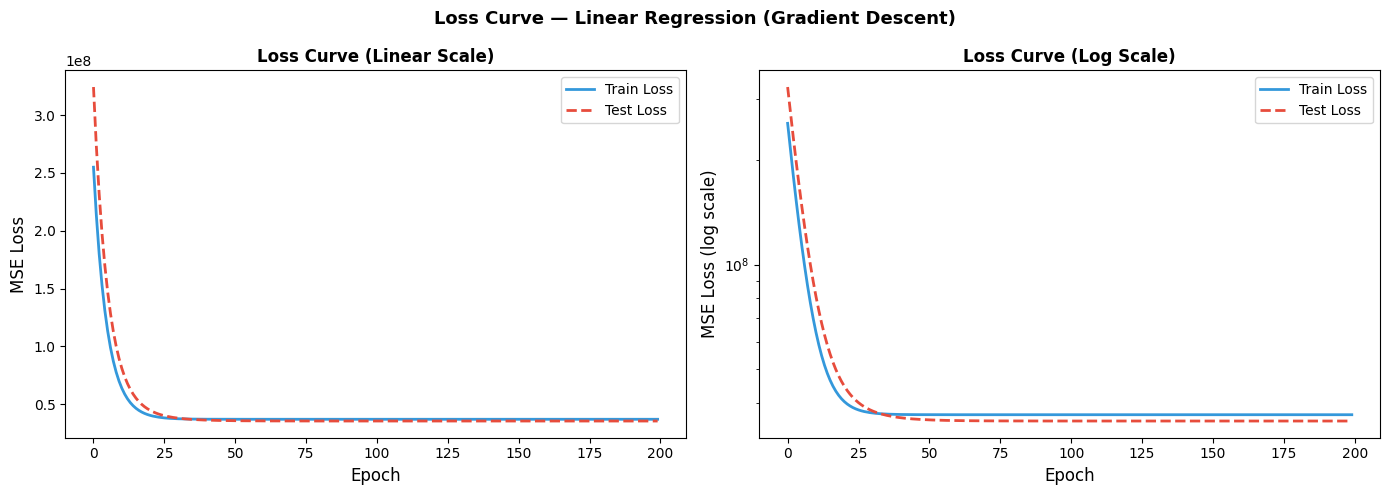

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(epochs), train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(range(epochs), test_losses,  label='Test Loss',  color='#e74c3c',
             linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Loss Curve (Linear Scale)', fontweight='bold')
axes[0].legend()

axes[1].plot(range(epochs), train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(range(epochs), test_losses,  label='Test Loss',  color='#e74c3c',
             linewidth=2, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss (log scale)', fontsize=12)
axes[1].set_title('Loss Curve (Log Scale)', fontweight='bold')
axes[1].legend()

plt.suptitle('Loss Curve — Linear Regression (Gradient Descent)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Scatter Plot — Before and After the Regression Line

**Before:** raw scatter of Age vs Charges, coloured by smoker status.
**After:** the linear regression fit overlaid — the line captures the overall upward trend while the two clusters (smoker/non-smoker) remain visible.

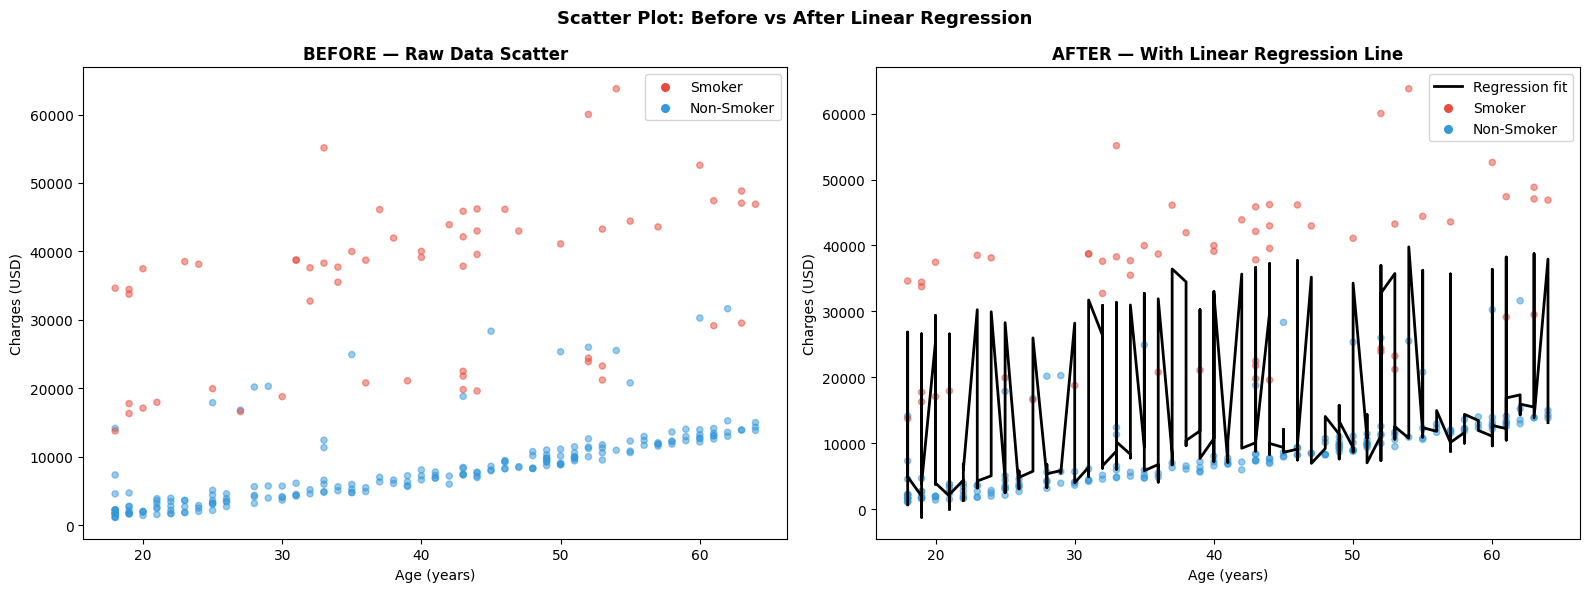

In [15]:
age_idx  = FEATURES.index('age')
x_raw    = X_test.values[:, age_idx]
y_pred_gd = sgd_model.predict(X_test_scaled)
sort_idx  = np.argsort(x_raw)

smoker_vals = df_encoded.loc[X_test.index, 'smoker'].values
colors_test = ['#e74c3c' if s == 1 else '#3498db' for s in smoker_vals]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(x_raw, y_test.values, c=colors_test, alpha=0.5, s=20)
axes[0].scatter([], [], color='#e74c3c', label='Smoker',     s=30)
axes[0].scatter([], [], color='#3498db', label='Non-Smoker', s=30)
axes[0].set_title('BEFORE — Raw Data Scatter', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Charges (USD)')
axes[0].legend()

axes[1].scatter(x_raw, y_test.values, c=colors_test, alpha=0.5, s=20)
axes[1].plot(x_raw[sort_idx], y_pred_gd[sort_idx], color='black', linewidth=2,
             label='Regression fit')
axes[1].scatter([], [], color='#e74c3c', label='Smoker',     s=30)
axes[1].scatter([], [], color='#3498db', label='Non-Smoker', s=30)
axes[1].set_title('AFTER — With Linear Regression Line', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Charges (USD)')
axes[1].legend()

plt.suptitle('Scatter Plot: Before vs After Linear Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10: Decision Tree Model

### Decision Tree Training

In [16]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_train_dt = dt_model.predict(X_train_scaled)
y_pred_test_dt  = dt_model.predict(X_test_scaled)

dt_train_mse = mean_squared_error(y_train, y_pred_train_dt)
dt_test_mse  = mean_squared_error(y_test,  y_pred_test_dt)
dt_r2        = r2_score(y_test, y_pred_test_dt)

print("Decision Tree")
print(f"  Train MSE : {dt_train_mse:,.2f}  |  Test MSE : {dt_test_mse:,.2f}")
print(f"  Train RMSE: {np.sqrt(dt_train_mse):,.2f}  |  Test RMSE: {np.sqrt(dt_test_mse):,.2f}")
print(f"  Test  R2  : {dt_r2:.4f}")

Decision Tree
  Train MSE : 18,000,216.11  |  Test MSE : 19,778,189.65
  Train RMSE: 4,242.67  |  Test RMSE: 4,447.27
  Test  R2  : 0.8924


### Decision Tree — Feature Importance

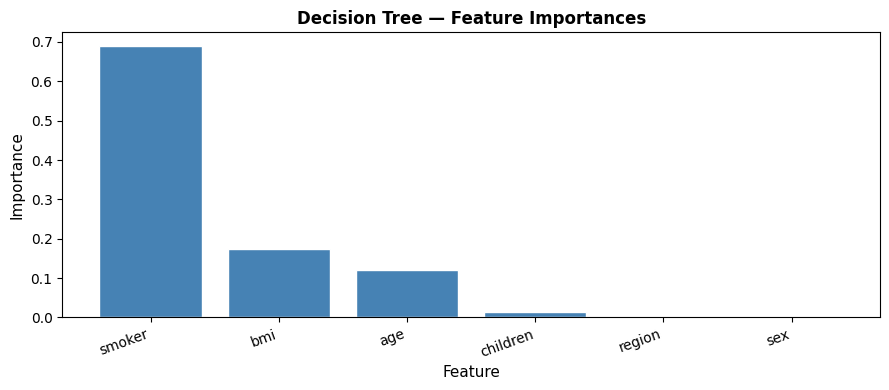

In [17]:
importances_dt = dt_model.feature_importances_
indices_dt     = np.argsort(importances_dt)[::-1]

plt.figure(figsize=(9, 4))
plt.bar(range(len(FEATURES)), importances_dt[indices_dt],
        color='steelblue', edgecolor='white')
plt.xticks(range(len(FEATURES)), [FEATURES[i] for i in indices_dt],
           rotation=20, ha='right')
plt.xlabel('Feature', fontsize=11)
plt.ylabel('Importance', fontsize=11)
plt.title('Decision Tree — Feature Importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Decision Tree — Actual vs Predicted

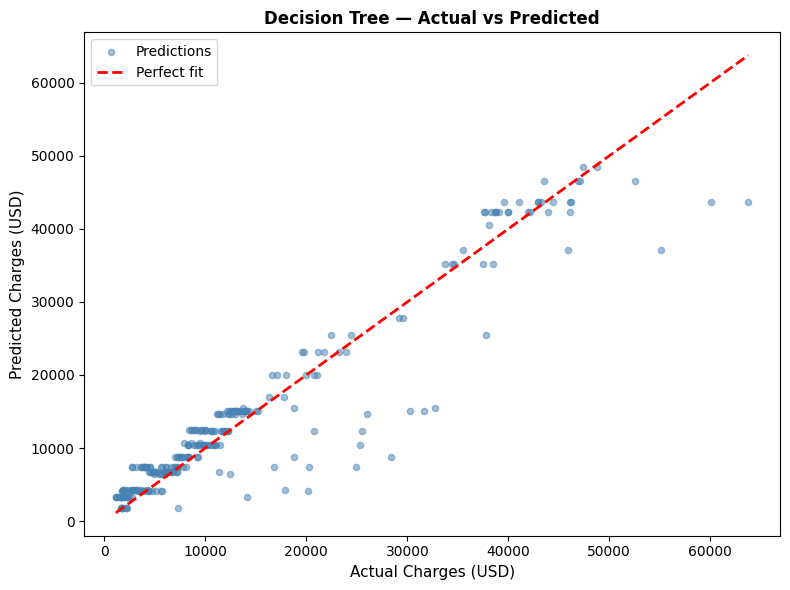

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_dt, color='steelblue', alpha=0.5, s=20,
            label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect fit')
plt.xlabel('Actual Charges (USD)', fontsize=11)
plt.ylabel('Predicted Charges (USD)', fontsize=11)
plt.title('Decision Tree — Actual vs Predicted', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Comparison: Linear Regression vs Decision Tree

In [19]:
print("=" * 57)
print(f"{'Metric':<20} {'Linear Reg (GD)':>17} {'Decision Tree':>15}")
print("=" * 57)
print(f"{'Test MSE':<20} {gd_test_mse:>17,.2f} {dt_test_mse:>15,.2f}")
print(f"{'Test RMSE':<20} {np.sqrt(gd_test_mse):>17,.2f} {np.sqrt(dt_test_mse):>15,.2f}")
print(f"{'Test MAE':<20} {mean_absolute_error(y_test,y_pred_gd):>17,.2f} "
      f"{mean_absolute_error(y_test,y_pred_test_dt):>15,.2f}")
print(f"{'Test R2':<20} {r2_score(y_test,y_pred_gd):>17.4f} {dt_r2:>15.4f}")
print("=" * 57)

Metric                 Linear Reg (GD)   Decision Tree
Test MSE                 35,493,102.79   19,778,189.65
Test RMSE                     5,957.61        4,447.27
Test MAE                      4,182.35        2,593.36
Test R2                         0.8068          0.8924


## Step 11: Random Forest Model

### Random Forest Training

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_test_rf  = rf_model.predict(X_test_scaled)

rf_train_mse = mean_squared_error(y_train, y_pred_train_rf)
rf_test_mse  = mean_squared_error(y_test,  y_pred_test_rf)
rf_r2        = r2_score(y_test, y_pred_test_rf)

print("Random Forest")
print(f"  Train MSE : {rf_train_mse:,.2f}  |  Test MSE : {rf_test_mse:,.2f}")
print(f"  Train RMSE: {np.sqrt(rf_train_mse):,.2f}  |  Test RMSE: {np.sqrt(rf_test_mse):,.2f}")
print(f"  Test  R2  : {rf_r2:.4f}")

Random Forest
  Train MSE : 5,077,154.90  |  Test MSE : 21,030,268.66
  Train RMSE: 2,253.25  |  Test RMSE: 4,585.88
  Test  R2  : 0.8856


### Random Forest — Feature Importance

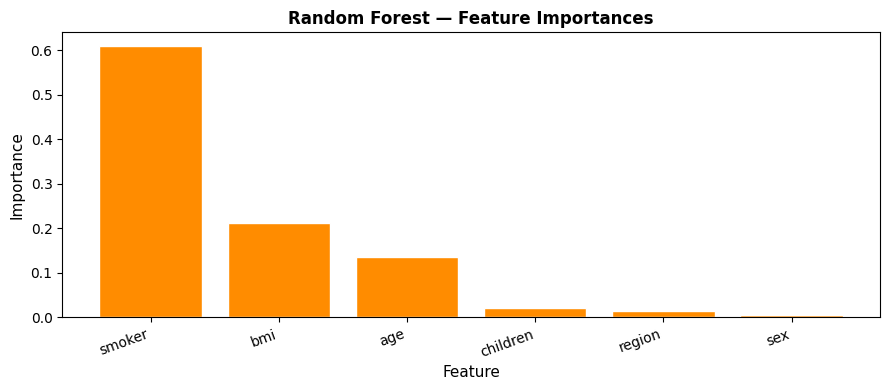

In [21]:
importances_rf = rf_model.feature_importances_
indices_rf     = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(9, 4))
plt.bar(range(len(FEATURES)), importances_rf[indices_rf],
        color='darkorange', edgecolor='white')
plt.xticks(range(len(FEATURES)), [FEATURES[i] for i in indices_rf],
           rotation=20, ha='right')
plt.xlabel('Feature', fontsize=11)
plt.ylabel('Importance', fontsize=11)
plt.title('Random Forest — Feature Importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Random Forest — Actual vs Predicted

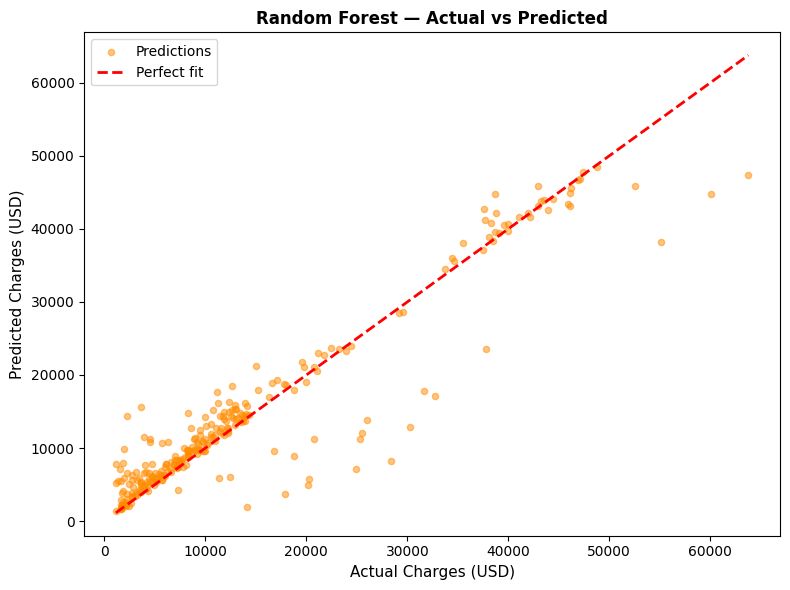

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_rf, color='darkorange', alpha=0.5, s=20,
            label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect fit')
plt.xlabel('Actual Charges (USD)', fontsize=11)
plt.ylabel('Predicted Charges (USD)', fontsize=11)
plt.title('Random Forest — Actual vs Predicted', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Final Comparison — All Three Models

In [23]:
print("=" * 75)
print(f"{'Metric':<20} {'Linear Reg (GD)':>17} {'Decision Tree':>15} {'Random Forest':>15}")
print("=" * 75)
rows = [
    ('Test MSE',  gd_test_mse,                         dt_test_mse,                         rf_test_mse),
    ('Test RMSE', np.sqrt(gd_test_mse),                 np.sqrt(dt_test_mse),                np.sqrt(rf_test_mse)),
    ('Test MAE',  mean_absolute_error(y_test,y_pred_gd), mean_absolute_error(y_test,y_pred_test_dt), mean_absolute_error(y_test,y_pred_test_rf)),
    ('Test R2',   r2_score(y_test,y_pred_gd),            dt_r2,                               rf_r2),
]
for metric, lr_v, dt_v, rf_v in rows:
    print(f"{metric:<20} {lr_v:>17,.2f} {dt_v:>15,.2f} {rf_v:>15,.2f}")
print("=" * 75)

scores    = {'Linear Regression (GD)': gd_test_mse,
             'Decision Tree':          dt_test_mse,
             'Random Forest':          rf_test_mse}
best_name = min(scores, key=scores.get)
print(f"\n>>> Best model (lowest Test MSE): {best_name}")

Metric                 Linear Reg (GD)   Decision Tree   Random Forest
Test MSE                 35,493,102.79   19,778,189.65   21,030,268.66
Test RMSE                     5,957.61        4,447.27        4,585.88
Test MAE                      4,182.35        2,593.36        2,566.62
Test R2                           0.81            0.89            0.89

>>> Best model (lowest Test MSE): Decision Tree


## Step 12: Save the Best Model and Make a Prediction

### Saving the Best Model and Scaler

In [24]:
model_map  = {
    'Linear Regression (GD)': sgd_model,
    'Decision Tree':          dt_model,
    'Random Forest':          rf_model,
}
best_model = model_map[best_name]

api_dir = os.path.join('..', 'API')
os.makedirs(api_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(api_dir, 'best_model.pkl'))
joblib.dump(scaler,     os.path.join(api_dir, 'scaler.pkl'))

print(f"Best model ({best_name}) saved to {api_dir}/best_model.pkl")
print(f"Scaler saved to {api_dir}/scaler.pkl")

Best model (Decision Tree) saved to ..\API/best_model.pkl
Scaler saved to ..\API/scaler.pkl


### Making a Prediction on One Data Point

We take one row from the test set, scale it, and predict the insurance charge.

In [25]:
single_sample        = X_test.iloc[[0]]
single_sample_scaled = scaler.transform(single_sample)
prediction           = best_model.predict(single_sample_scaled)[0]
actual               = y_test.iloc[0]

print("--- Single-Sample Prediction ---")
for col, val in zip(FEATURES, X_test.iloc[0]):
    print(f"  {col:10s}: {val}")
print(f"\n  Predicted Charge : ${prediction:,.2f}")
print(f"  Actual    Charge : ${actual:,.2f}")
print(f"  Error            : ${abs(prediction - actual):,.2f}")

--- Single-Sample Prediction ---
  age       : 49.0
  sex       : 1.0
  bmi       : 22.515
  children  : 0.0
  smoker    : 0.0
  region    : 0.0

  Predicted Charge : $12,504.99
  Actual    Charge : $8,688.86
  Error            : $3,816.14


### Final Model Summary

In [26]:
print("=" * 60)
print("        FINAL PROJECT SUMMARY")
print("=" * 60)
print("\n Dataset:")
print("   Source  : Medical Cost Personal Dataset (Kaggle)")
print(f"  Records : {df_encoded.shape[0]} individuals")
print(f"  Features: {len(FEATURES)} inputs  Target: insurance charges (USD)")
print("\n Models Trained:")
print(f"  1. Linear Regression (OLS)  — Test RMSE: ${np.sqrt(lr_test_mse):,.2f}")
print(f"  2. Linear Regression (GD)   — Test RMSE: ${np.sqrt(gd_test_mse):,.2f}")
print(f"  3. Decision Tree            — Test RMSE: ${np.sqrt(dt_test_mse):,.2f}")
print(f"  4. Random Forest            — Test RMSE: ${np.sqrt(rf_test_mse):,.2f}")
print(f"\n Best Model : {best_name}")
print(f"  Test RMSE : ${np.sqrt(scores[best_name]):,.2f}")
print(f"  Test R2   : {r2_score(y_test, best_model.predict(X_test_scaled)):.4f}")
print("=" * 60)

        FINAL PROJECT SUMMARY

 Dataset:
   Source  : Medical Cost Personal Dataset (Kaggle)
  Records : 1337 individuals
  Features: 6 inputs  Target: insurance charges (USD)

 Models Trained:
  1. Linear Regression (OLS)  — Test RMSE: $5,957.61
  2. Linear Regression (GD)   — Test RMSE: $5,957.61
  3. Decision Tree            — Test RMSE: $4,447.27
  4. Random Forest            — Test RMSE: $4,585.88

 Best Model : Decision Tree
  Test RMSE : $4,447.27
  Test R2   : 0.8924


## Step 13: Prediction Script for Task 2

Standalone function that loads the saved model and makes a prediction — this is used directly by the FastAPI endpoint in Task 2.

In [27]:
import joblib, os
import pandas as pd
import numpy as np

_model  = joblib.load(os.path.join('..', 'API', 'best_model.pkl'))
_scaler = joblib.load(os.path.join('..', 'API', 'scaler.pkl'))

FEATURES = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
REGION_MAP = {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}

def predict_charges(age, sex, bmi, children, smoker, region):
    sex_enc    = 0 if sex    == 'female' else 1
    smoker_enc = 0 if smoker == 'no'     else 1
    region_enc = REGION_MAP[region]
    row        = pd.DataFrame([[age, sex_enc, bmi, children, smoker_enc, region_enc]],
                               columns=FEATURES)
    row_scaled = _scaler.transform(row)
    return round(float(_model.predict(row_scaled)[0]), 2)

sample = predict_charges(
    age=35, sex='male', bmi=28.5,
    children=2, smoker='no', region='northeast'
)
print(f"Sample prediction: ${sample:,.2f}")

Sample prediction: $7,407.17
